In [4]:
from google.colab import files
uploaded = files.upload()

Saving covid_19_india.csv to covid_19_india.csv


In [5]:
import pandas as pd
df=pd.read_csv("covid_19_india.csv")
df.head()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [6]:
df.shape

(18110, 9)

In [7]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[ns]')

In [14]:
df['ConfirmedIndianNational'].unique()
df['ConfirmedForeignNational'].unique()

array(['0', '1', '2', '14', '3', '9', '7', '11', '10', '8', '6', '-'],
      dtype=object)

In [15]:
df['ConfirmedIndianNational'] = df['ConfirmedIndianNational'].replace('-', 0)
df['ConfirmedForeignNational'] = df['ConfirmedForeignNational'].replace('-', 0)

In [16]:
df['ConfirmedIndianNational'] = df['ConfirmedIndianNational'].astype(int)
df['ConfirmedForeignNational'] = df['ConfirmedForeignNational'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      18110 non-null  datetime64[ns]
 1   State/UnionTerritory      18110 non-null  object        
 2   ConfirmedIndianNational   18110 non-null  int64         
 3   ConfirmedForeignNational  18110 non-null  int64         
 4   Cured                     18110 non-null  int64         
 5   Deaths                    18110 non-null  int64         
 6   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 990.5+ KB


In [25]:
# Which state had the highest total confirmed cases?
df.groupby('State/UnionTerritory')['Confirmed'].max().sort_values(ascending=False).head(10)

,Confirmed
State/UnionTerritory,
Maharashtra,6363442
Maharashtra***,6229596
Kerala,3586693
Karnataka,2921049
Karanataka,2885238
Tamil Nadu,2579130
Andhra Pradesh,1985182
Uttar Pradesh,1708812
West Bengal,1534999


In [26]:
# What was the total number of deaths across India?
df['Deaths'].sum()

np.int64(73389005)

In [27]:
# Get the LAST recorded value for each state (the final cumulative total)
total_deaths = df.groupby('State/UnionTerritory')['Deaths'].max().sum()
print(f"Total Deaths across India: {total_deaths:,}")

Total Deaths across India: 621,910


In [30]:
# Which month saw the peak confirmed cases?
df['Month'] = df['Date'].dt.month_name()
monthly = df.groupby('Month')['Confirmed'].max().sort_values(ascending=False)
print(monthly)

Month
August       6363442
July         6296756
June         6051633
May          5731815
April        4539553
March        2773436
February     2146777
January      2023814
December     1928603
November     1820059
October      1672858
September    1366129
Name: Confirmed, dtype: int64


In [31]:
# Recovery rate (corrected for cumulative data)
total_confirmed = df.groupby('State/UnionTerritory')['Confirmed'].max().sum()
total_cured = df.groupby('State/UnionTerritory')['Cured'].max().sum()
recovery_rate = (total_cured / total_confirmed) * 100
print(f"Recovery Rate: {recovery_rate:.2f}%")

Recovery Rate: 97.16%


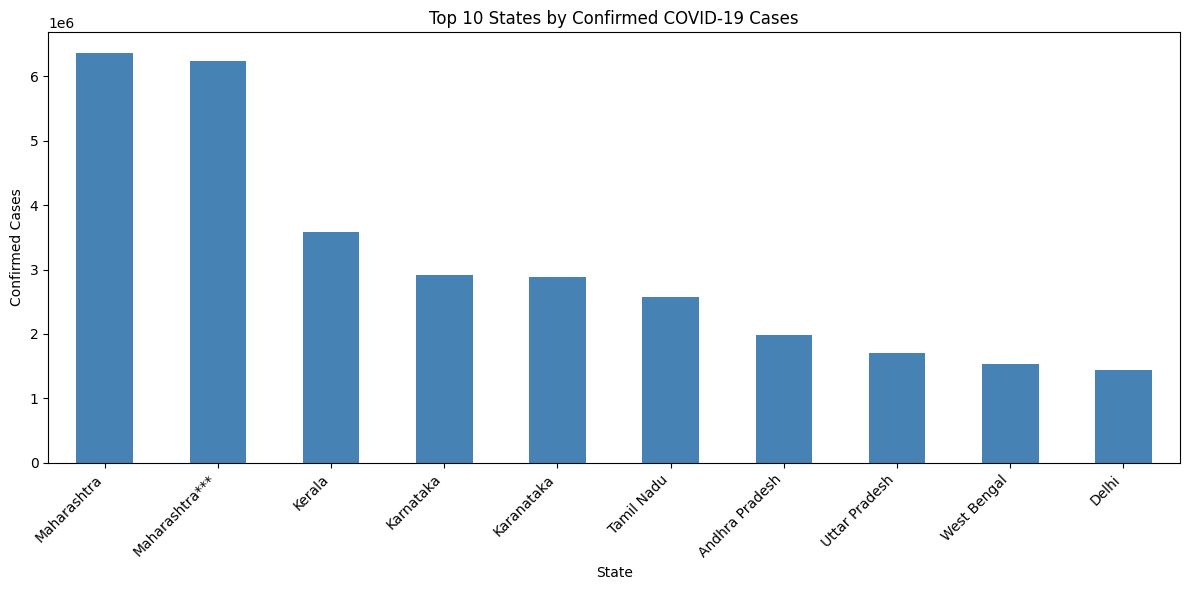

In [32]:
# Plot top 10 states by confirmed cases (your first chart!)
import matplotlib.pyplot as plt

top10 = df.groupby('State/UnionTerritory')['Confirmed'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Confirmed COVID-19 Cases')
plt.xlabel('State')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
# Spotted this Data quality issue through the chart above
df['State/UnionTerritory'] = df['State/UnionTerritory'].str.strip()
df['State/UnionTerritory'] = df['State/UnionTerritory'].replace({
    'Karanataka': 'Karnataka',
    'Maharashtra***': 'Maharashtra'
})

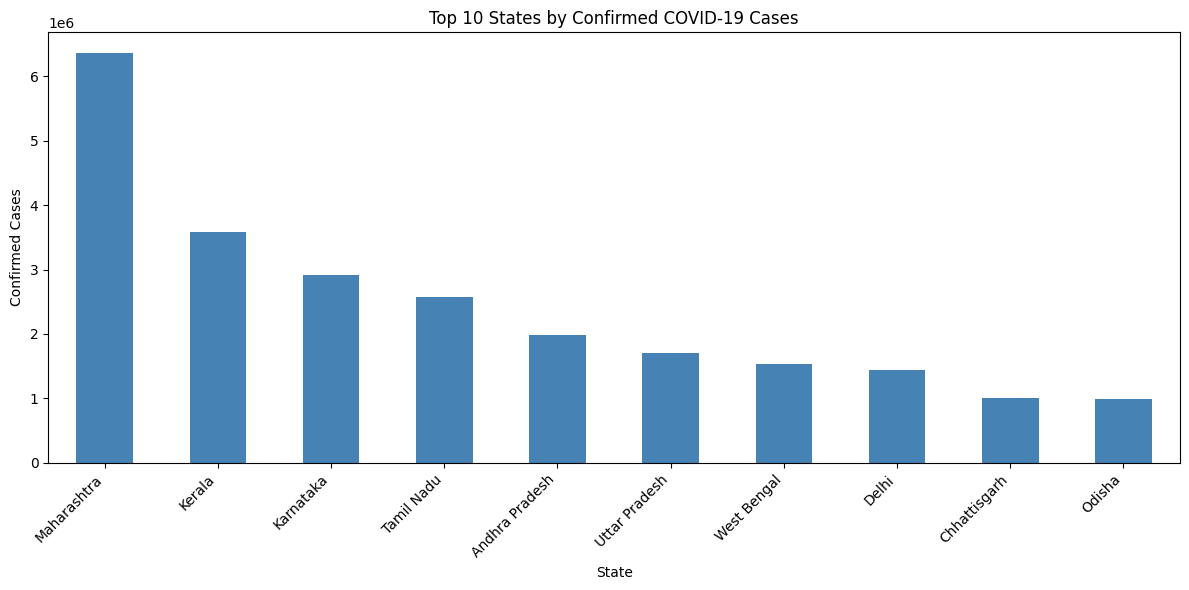

In [34]:
# Plot top 10 states by confirmed cases (your first chart!)
import matplotlib.pyplot as plt

top10 = df.groupby('State/UnionTerritory')['Confirmed'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Confirmed COVID-19 Cases')
plt.xlabel('State')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

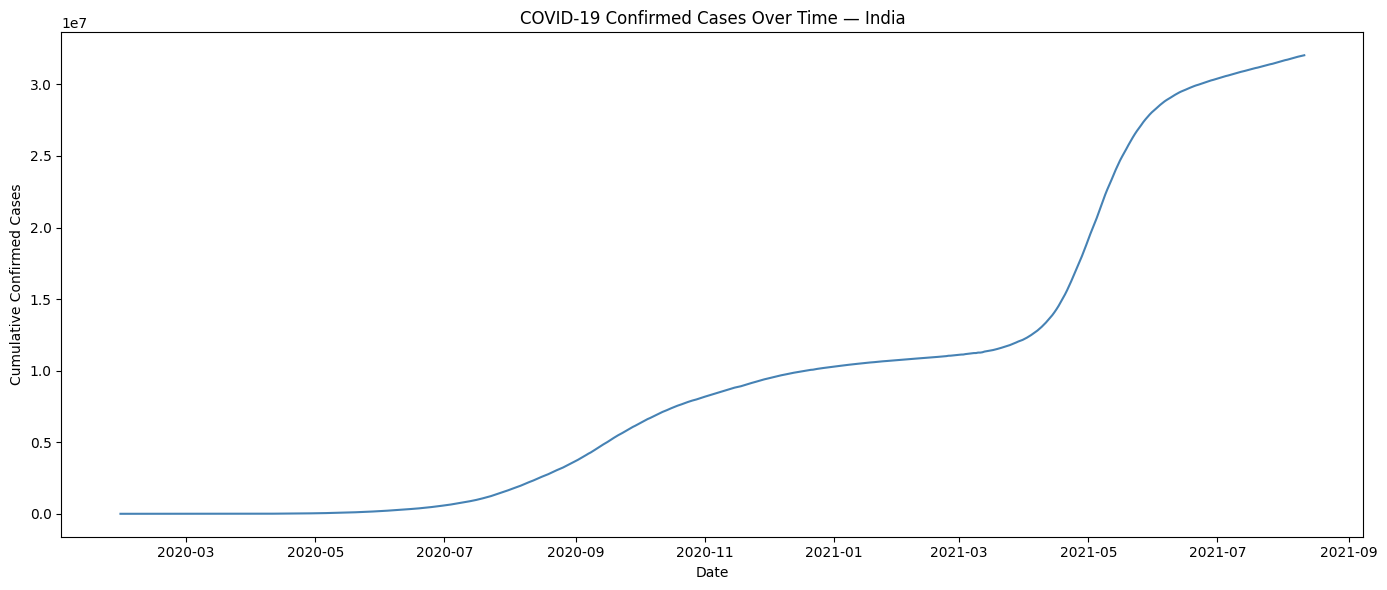

In [35]:
# Aggregate confirmed cases across all states by date
india_daily = df.groupby('Date')['Confirmed'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(india_daily['Date'], india_daily['Confirmed'], color='steelblue', linewidth=1.5)
plt.title('COVID-19 Confirmed Cases Over Time — India')
plt.xlabel('Date')
plt.ylabel('Cumulative Confirmed Cases')
plt.tight_layout()
plt.show()